In [52]:
!nvidia-smi

Fri Jan 30 02:15:30 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   47C    P0             27W /   70W |     376MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [53]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import sklearn
import seaborn as sns
from tensorflow import keras
from keras import layers
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [54]:
def shuffle_data(data, test_ratio):
  shuffled_indices = np.random.permutation(len(data))
  print(len(data))
  test_set_size = int(len(data) * test_ratio)
  test_indices = shuffled_indices[:test_set_size]
  train_indices = shuffled_indices[test_set_size:]
  return data.iloc[train_indices], data.iloc[test_indices]

In [55]:
file_path = "housing.csv"

df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "camnugent/california-housing-prices",
  file_path,
)

housing_train_df, housing_test_df = shuffle_data(df, 0.2)

Using Colab cache for faster access to the 'california-housing-prices' dataset.
20640


<Axes: xlabel='longitude', ylabel='latitude'>

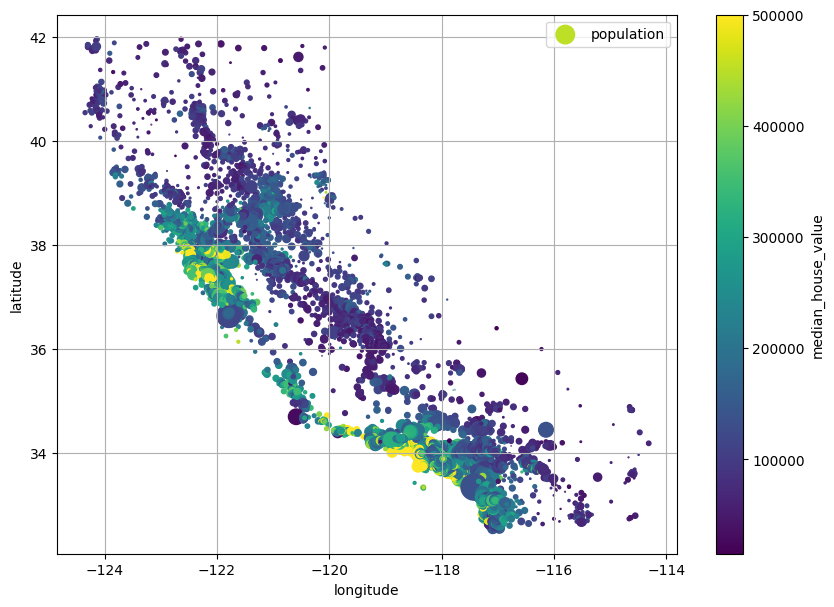

In [56]:
df.plot(kind="scatter", x="longitude", y="latitude", grid=True,
s=df["population"] / 100, label="population",
c="median_house_value", cmap="viridis", colorbar=True,
legend=True, sharex=False, figsize=(10, 7))

<Axes: xlabel='longitude', ylabel='latitude'>

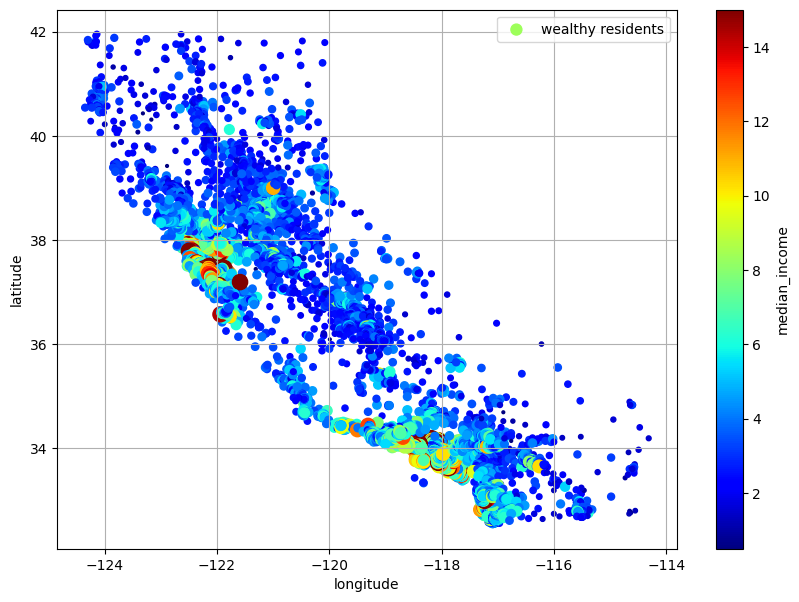

In [57]:
df.plot(kind="scatter", x="longitude", y="latitude", grid=True,
s=df["median_income"]*8, label="wealthy residents",
c="median_income", cmap="jet", colorbar=True,
legend=True, sharex=False, figsize=(10, 7))

<Axes: xlabel='longitude', ylabel='latitude'>

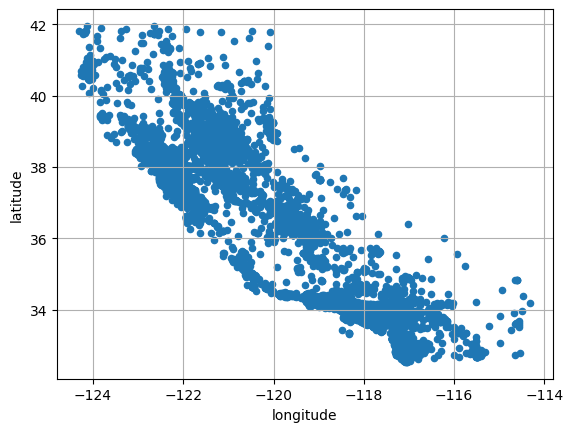

In [58]:
housing_train_df.plot(kind='scatter', x='longitude', y='latitude', grid=True)

In [59]:
# Separate features and target
X_train = housing_train_df.drop("median_house_value", axis=1)
y_train = housing_train_df["median_house_value"].copy()
X_test = housing_test_df.drop("median_house_value", axis=1)
y_test = housing_test_df["median_house_value"].copy()

# Handle missing values
median_bedrooms = X_train["total_bedrooms"].median()
X_train["total_bedrooms"] = X_train["total_bedrooms"].fillna(median_bedrooms)
X_test["total_bedrooms"] = X_test["total_bedrooms"].fillna(median_bedrooms)

# One-hot encoding
X_train = pd.get_dummies(X_train, columns=["ocean_proximity"], dtype=float)
X_test = pd.get_dummies(X_test, columns=["ocean_proximity"], dtype=float)

# Ensure X_test has the same columns as X_train
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

# Normalize numerical features
numerical_cols = [col for col in X_train.columns if 'ocean_proximity' not in col]

scaler = StandardScaler()
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
X_train.head()

X_train shape: (16512, 13)
X_test shape: (4128, 13)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
6406,0.779938,-0.708877,0.349906,0.109445,-0.187725,-0.163051,-0.178724,0.718338,0.0,1.0,0.0,0.0,0.0
4053,0.575260,-0.699495,-0.206324,0.121360,0.310738,-0.294506,0.237799,-0.083711,1.0,0.0,0.0,0.0,0.0
2409,0.071053,0.449745,0.429367,-0.811650,-0.841214,-0.745335,-0.859832,-0.965100,0.0,1.0,0.0,0.0,0.0
15644,-1.416609,1.007947,1.859673,0.376609,1.155026,0.760663,1.296135,-0.689046,0.0,0.0,0.0,1.0,0.0
1609,-1.241883,1.040782,-0.444709,-0.737871,-0.791129,-1.024125,-0.807439,-0.396269,0.0,0.0,0.0,1.0,0.0


In [60]:
model = keras.models.Sequential([
    layers.Dense(128, activation="relu", input_shape=X_train.shape[1:]),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(64, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(32, activation="relu"),
    layers.Dense(1)
])

model.compile(loss="mean_squared_error", optimizer="adam")

history = model.fit(X_train, y_train, epochs=60, validation_split=0.2)

Epoch 1/60


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


413/413 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 55489875968.0000 - val_loss: 56569352192.0000
Epoch 2/60
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 55301533696.0000 - val_loss: 53552209920.0000
Epoch 3/60
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 51205808128.0000 - val_loss: 45776666624.0000
Epoch 4/60
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 42792550400.0000 - val_loss: 34259152896.0000
Epoch 5/60
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 31318927360.0000 - val_loss: 22407682048.0000
Epoch 6/60
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 20050401280.0000 - val_loss: 12556259328.0000
Epoch 7/60
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 11675405312.0000 - val_loss: 6732307968.0000
Epoch 8/60
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 7559771136.0000 - val_loss: 4769417216.0000
Epoch 9/60
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 6122332160.0000 - val_loss: 4213718784.0000
Epoch 10/60
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 5

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


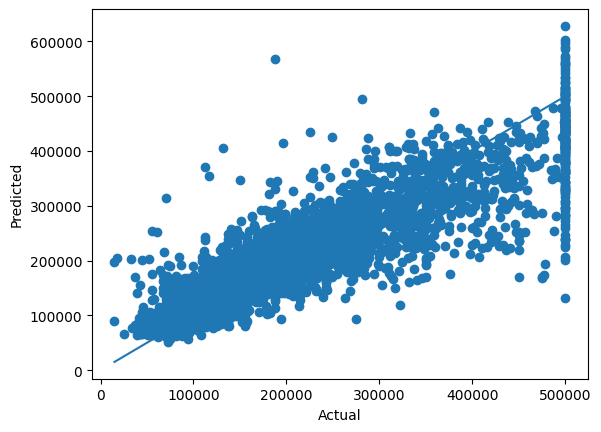

In [65]:
y_pred = model.predict(X_test).flatten()

plt.scatter(y_test, y_pred)
plt.plot([y_train.min(), y_train.max()],
         [y_train.min(), y_train.max()])
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()